In [1]:
import os
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import read_dataset

plt.rcParams.update({'font.size': 18})
sns.set_style("darkgrid")

## Correlation pruning
##### ⚠️ Please be sure to run this notebook after [1.3-Feature_Extraction](1.3-Feature_Extraction.ipynb)
##### ℹ️ This notebook overwrites 4 files in the `dataset/1-preprocessed` folder
Prior to feature selection, we're going to prune highly correlated (thus most probably redundant) features.

In [2]:
# 14s
train_x, _ = read_dataset(stage='preprocessed', use_cache=False)
train_discarded_x, _ = read_dataset(stage='preprocessed', discarded=True, use_cache=False)
valid_x = read_dataset(stage='preprocessed', dataset='valid')
test_x = read_dataset(stage='preprocessed', dataset='test')
base_features = ['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']

In [3]:
# 16s
correlation_matrix = train_x.drop(base_features, axis=1).corr()

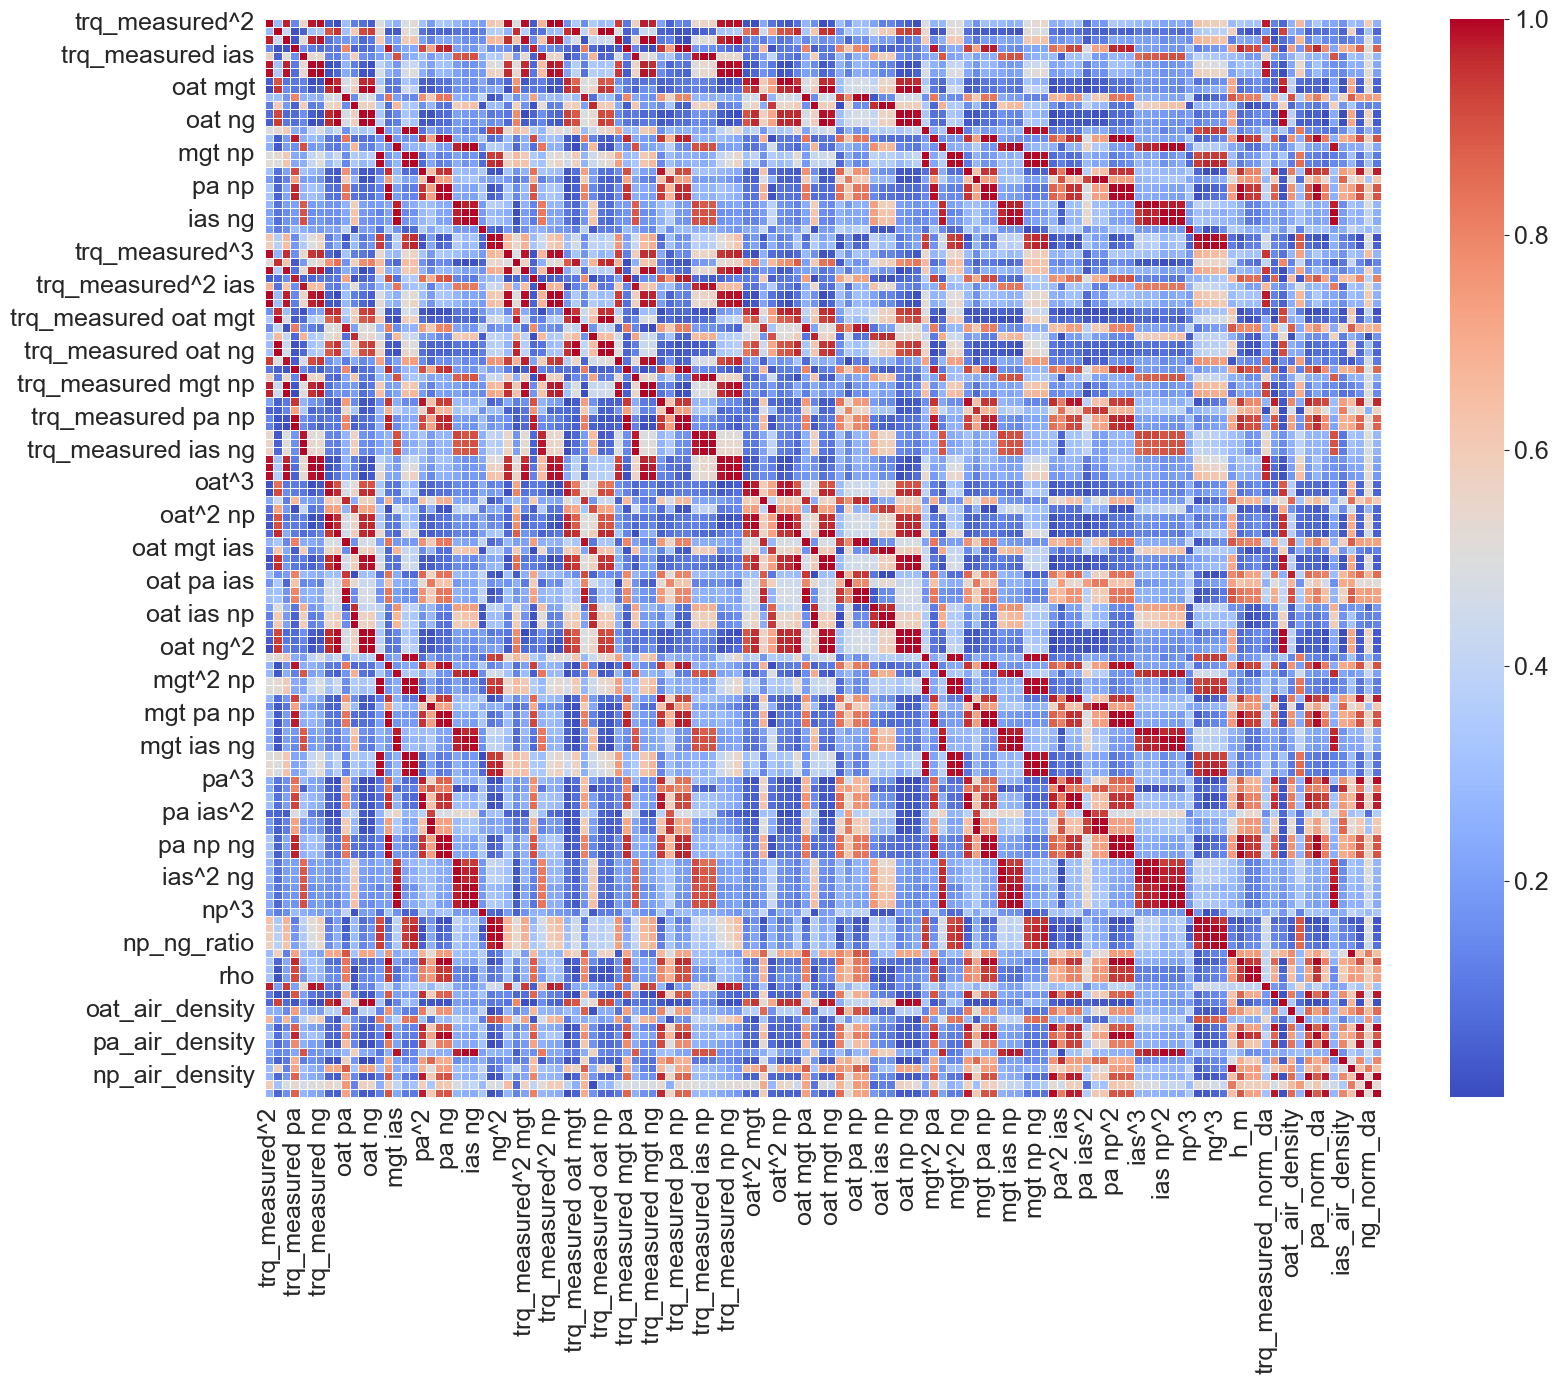

In [4]:
# 1s
plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix.abs(), annot=False, fmt=".2f", linewidths=0.4, cbar=True, cmap='coolwarm')
plt.show()

### Why are `air_density` features almost perfectly correlated?
Because they have a small variability compared to that of $\rho$.

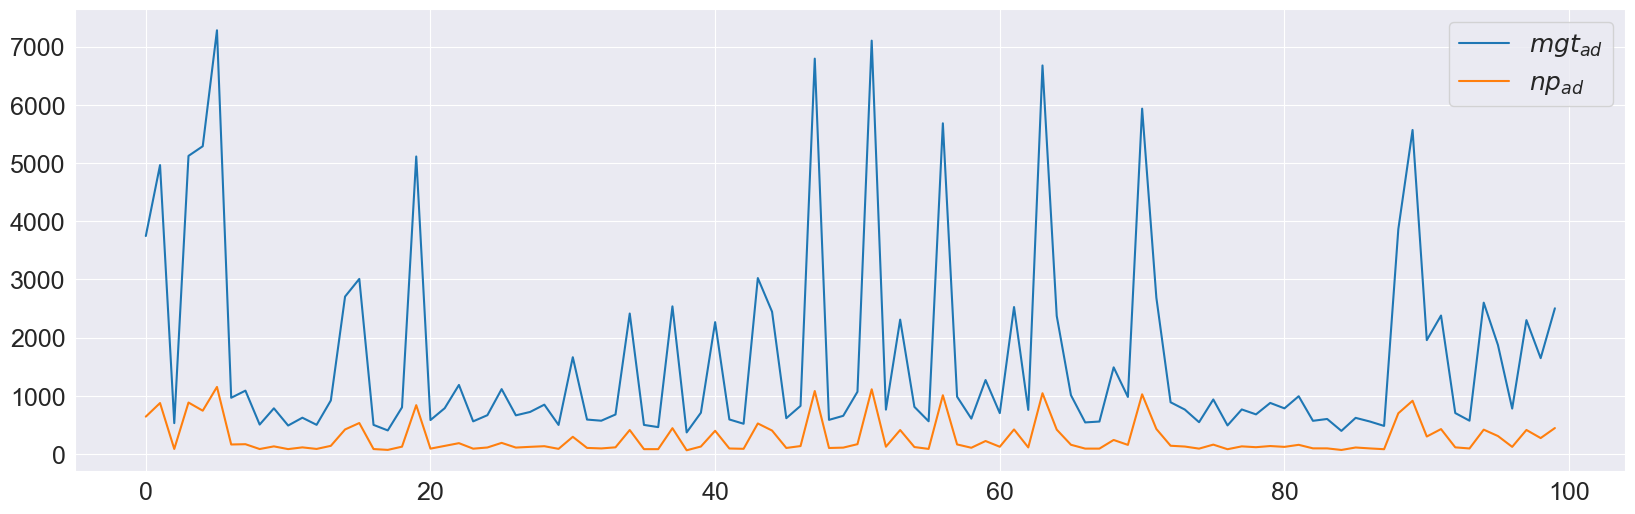

In [5]:
# 0s
ax = train_x['mgt_air_density'][:100].plot(figsize=(20, 6), label='$mgt_{ad}$')
(train_x['np_air_density'][:100]).plot(ax=ax, label='$np_{ad}$')
ax.legend(loc='upper right')

Ok, let's go back to feature selection by correlation pruning.

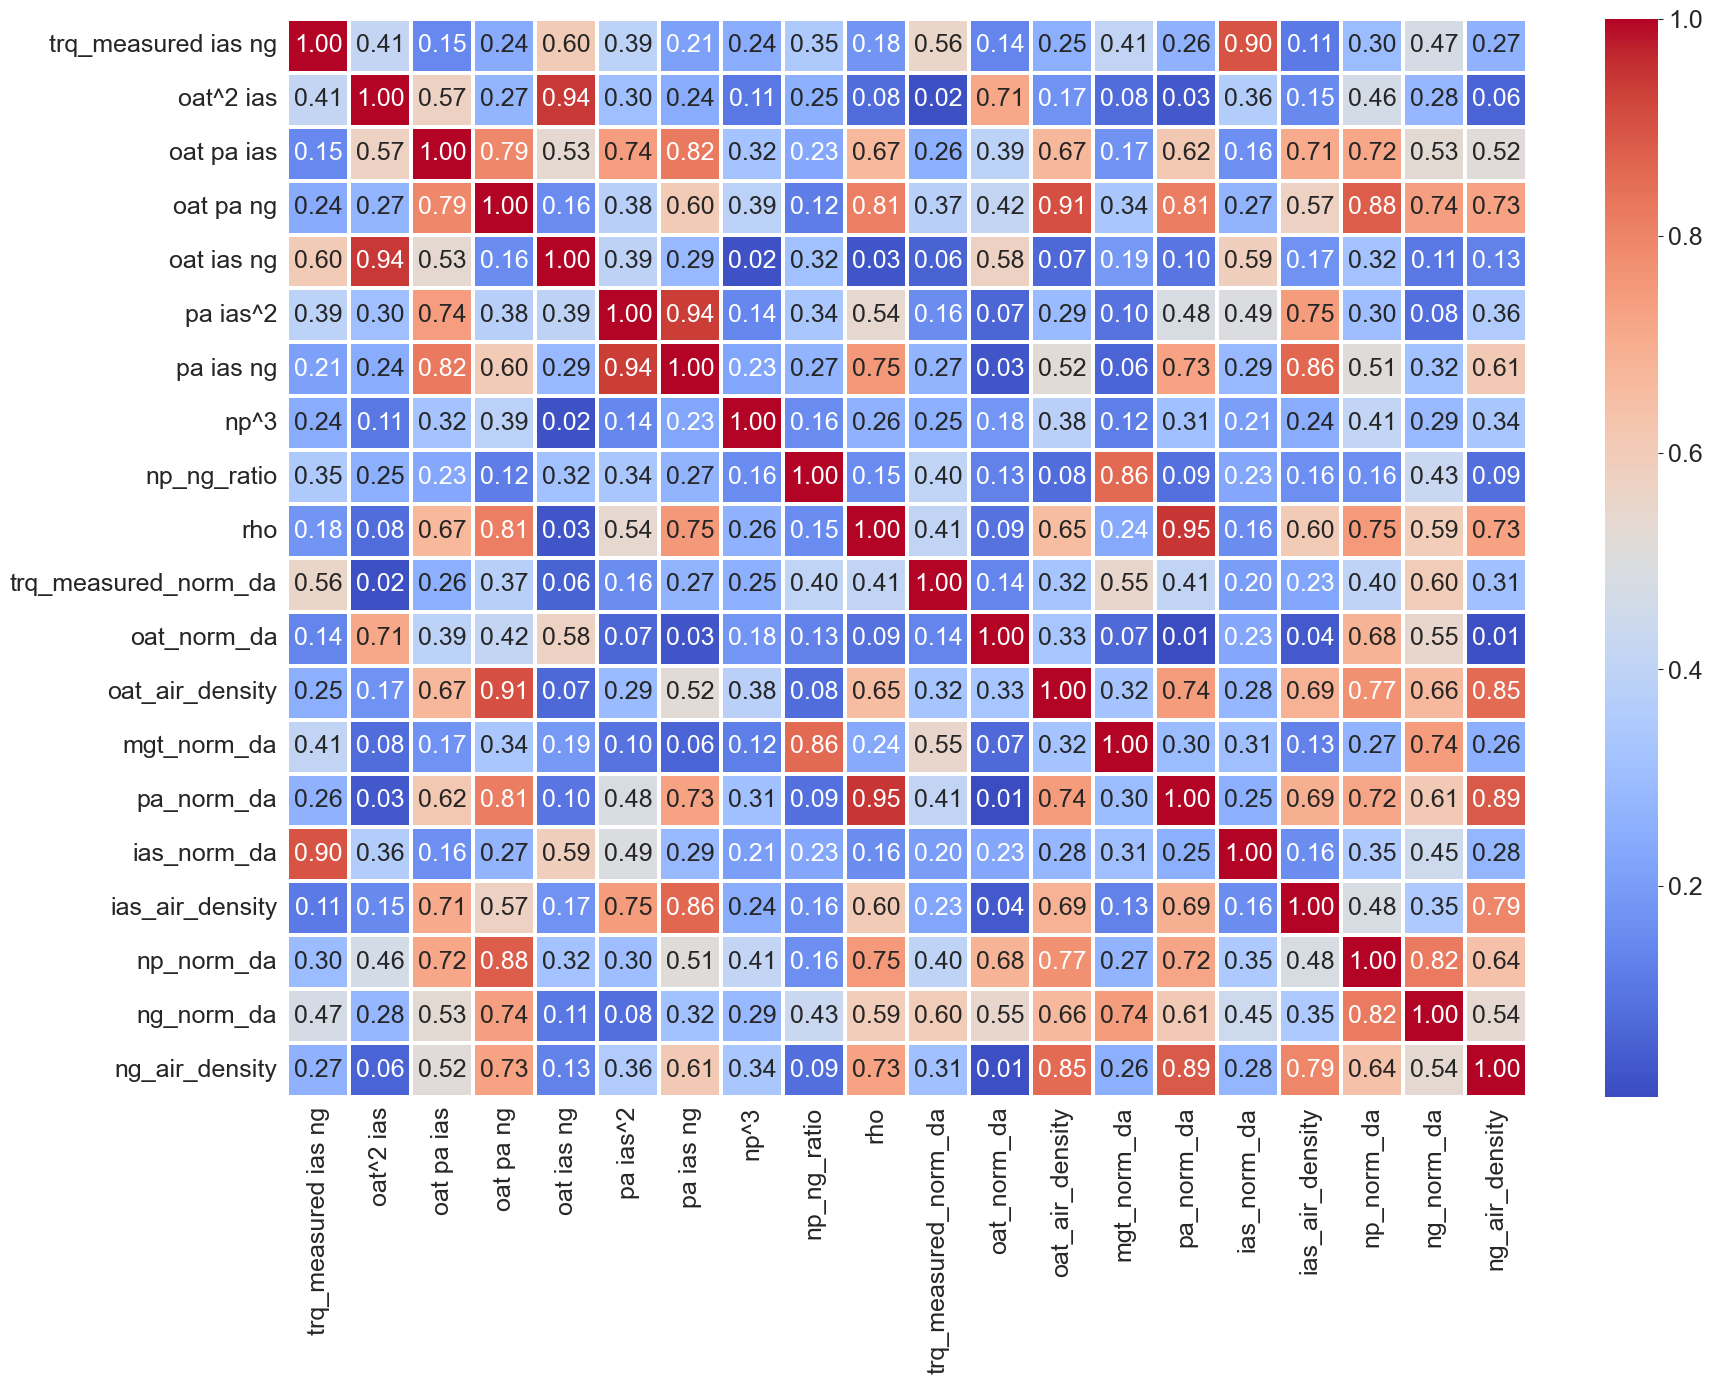

In [9]:
# 1s
threshold = 0.95  # 0.925 <-- More interpretable

high_corr_pairs = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.add((correlation_matrix.columns[i], correlation_matrix.columns[j]))

# Determine which features to drop (just pick one from each pair)
features_to_drop = set([pair[1] for pair in high_corr_pairs])
# Quasi-Occam's razor criterion
# features_to_drop = set([pair[1] if len(pair[0]) < len(pair[0]) else pair[0] for pair in high_corr_pairs])

plt.figure(figsize=(20, 14))
pruned_correlation_matrix = correlation_matrix.drop(features_to_drop, axis=0).drop(features_to_drop, axis=1).abs()
sns.heatmap(pruned_correlation_matrix, annot=True, fmt=".2f", linewidths=1.5, cbar=True, cmap='coolwarm')
plt.show()

Other than the non highly correlated extracted features, we also keep all the original features except for:
- `np` - It was proved in *1.2* to be linear dependent from `ng`.
- `ias` and `pa` - They represent environmental factors. During some PyKAN training we found that these features are not very relevant. However, we don't remove them completely, as they are embedded in the calculation of `air_density` ($\rho$).

In [10]:
base_features_to_drop = ['np', 'ias', 'pa']  # ['ias'] <-- Less interpretable

In [11]:
# 18s
os.makedirs('../dataset/1-preprocessed', exist_ok=True)
(train_x.drop(list(features_to_drop) + base_features_to_drop, axis=1)
 .to_csv('../dataset/1-preprocessed/X_train.csv', index=False))
(train_discarded_x.drop(list(features_to_drop) + base_features_to_drop, axis=1)
 .to_csv('../dataset/1-preprocessed/X_train_discarded.csv', index=False))
(valid_x.drop(list(features_to_drop) + base_features_to_drop, axis=1)
 .to_csv('../dataset/1-preprocessed/X_valid.csv', index=False))
(test_x.drop(list(features_to_drop) + base_features_to_drop, axis=1)
 .to_csv('../dataset/1-preprocessed/X_test.csv', index=False))